In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import Counter
import tiktoken

# Set up paths
dataset_dir = Path("../data")

In [2]:
sysml_files = []
# Collect all .sysml files and their line counts
for sample_dir in sorted(dataset_dir.iterdir()):
    if sample_dir.is_dir() and sample_dir.name.isdigit():
        sysml_file = sample_dir / f"{sample_dir.name}.sysml"
        if sysml_file.exists():
            with open(sysml_file, 'r', encoding='utf-8') as f:
                line_count = len(f.readlines())
            sysml_files.append({
                'id': sample_dir.name,
                'file': sysml_file,
                'lines': line_count
            })

print(f"Found {len(sysml_files)} SysML files")
print(f"Total lines: {sum(f['lines'] for f in sysml_files):,}")
print(f"Average lines per file: {np.mean([f['lines'] for f in sysml_files]):.1f}")
print(f"Median lines per file: {np.median([f['lines'] for f in sysml_files]):.1f}")

# Line count distribution
line_counts = [f['lines'] for f in sysml_files]
print(f"\nLine count distribution:")
print(f"Min: {min(line_counts)}")
print(f"Max: {max(line_counts)}")
print(f"25th percentile: {np.percentile(line_counts, 25):.1f}")
print(f"75th percentile: {np.percentile(line_counts, 75):.1f}")


# Show files with most/least lines
print(f"\nTop 5 files with most lines:")
for f in sorted(sysml_files, key=lambda x: x['lines'], reverse=True)[:5]:
    print(f"  {f['id']}: {f['lines']} lines")

print(f"\nTop 5 files with least lines:")
for f in sorted(sysml_files, key=lambda x: x['lines'])[:5]:
    print(f"  {f['id']}: {f['lines']} lines")


Found 1935 SysML files
Total lines: 708,182
Average lines per file: 366.0
Median lines per file: 376.0

Line count distribution:
Min: 9
Max: 2734
25th percentile: 289.0
75th percentile: 447.0

Top 5 files with most lines:
  000350: 2734 lines
  000303: 2726 lines
  000365: 2726 lines
  000355: 2365 lines
  000308: 2333 lines

Top 5 files with least lines:
  000097: 9 lines
  000013: 12 lines
  000023: 13 lines
  000026: 13 lines
  000012: 14 lines


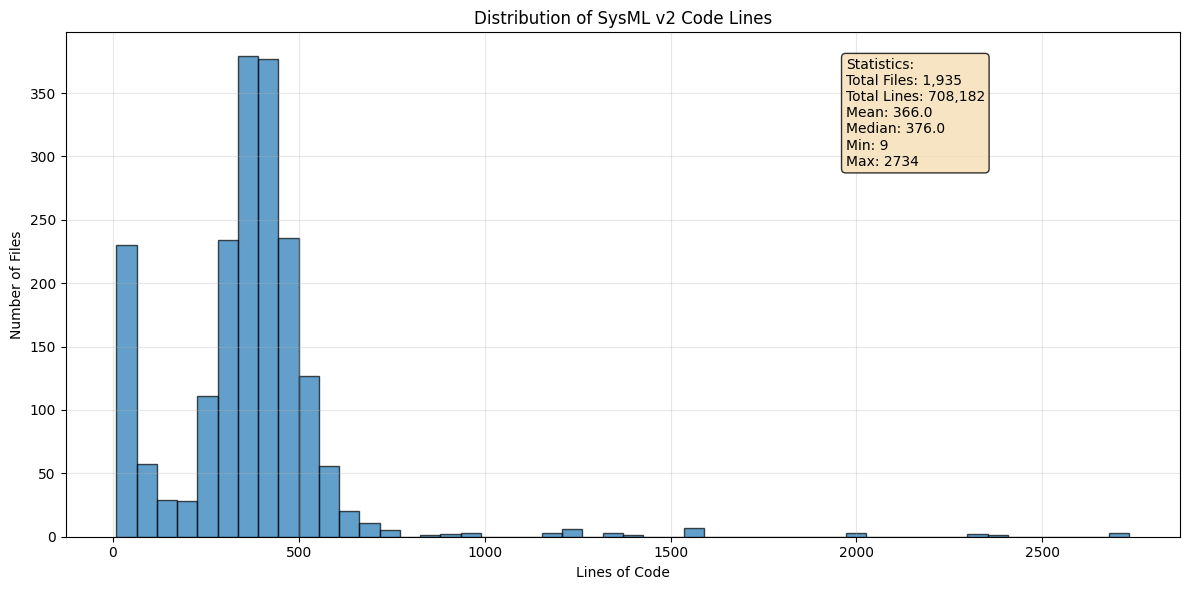

In [3]:
# Create histogram
plt.figure(figsize=(12, 6))
plt.hist(line_counts, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Lines of Code')
plt.ylabel('Number of Files')
plt.title('Distribution of SysML v2 Code Lines')
plt.grid(True, alpha=0.3)

# Add statistics text
stats_text = f"""Statistics:
Total Files: {len(sysml_files):,}
Total Lines: {sum(line_counts):,}
Mean: {np.mean(line_counts):.1f}
Median: {np.median(line_counts):.1f}
Min: {min(line_counts)}
Max: {max(line_counts)}"""
plt.text(0.7, 0.95, stats_text, transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

Category Distribution (1935 total samples):
  aerospace: 158 (8.2%)
  automotive: 304 (15.7%)
  electronics: 368 (19.0%)
  energy: 70 (3.6%)
  industrial: 398 (20.6%)
  medical: 404 (20.9%)
  other: 122 (6.3%)
  software: 111 (5.7%)


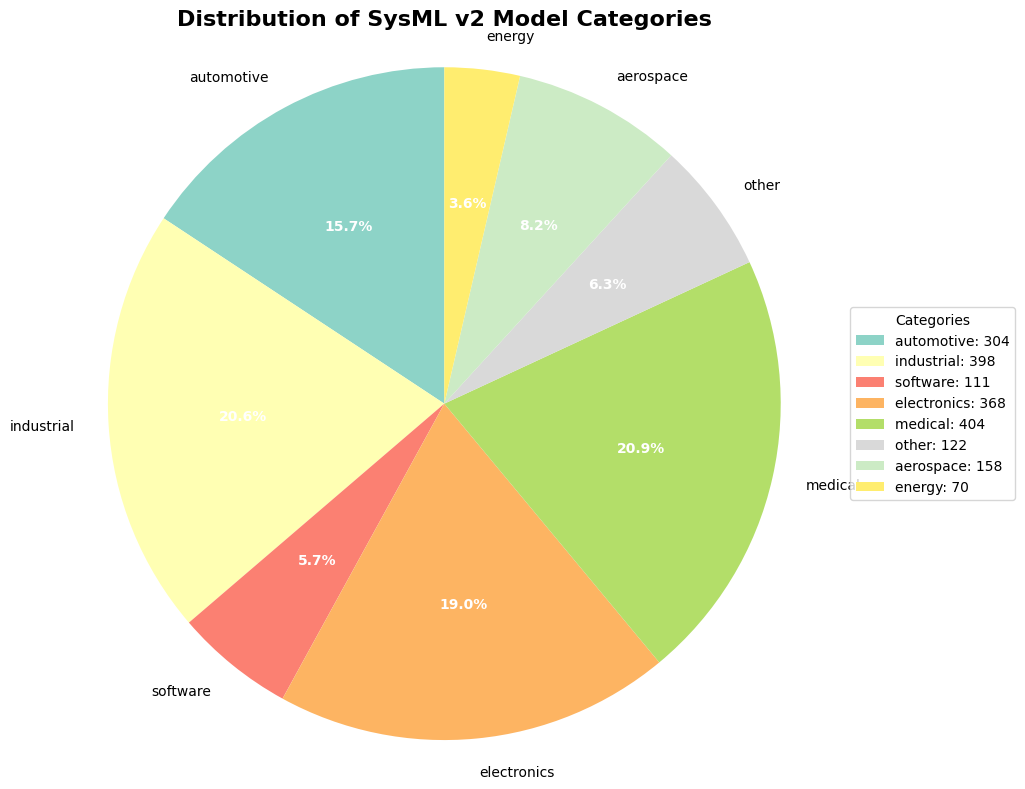

In [4]:
# Category distribution analysis
category_counts = {}
total_samples = 0

# Read category from meta.json files
for sample_dir in sorted(dataset_dir.iterdir()):
    if sample_dir.is_dir() and sample_dir.name.isdigit():
        meta_file = sample_dir / "meta.json"
        if meta_file.exists():
            try:
                with open(meta_file, 'r', encoding='utf-8') as f:
                    meta_data = json.load(f)
                category = meta_data.get('category', 'not processed')
                if category == 'unknown':
                    category = 'other'
                category_counts[category] = category_counts.get(category, 0) + 1
                total_samples += 1
            except:
                category_counts['error'] = category_counts.get('error', 0) + 1
                total_samples += 1

print(f"Category Distribution ({total_samples} total samples):")
for category, count in sorted(category_counts.items()):
    percentage = (count / total_samples) * 100
    print(f"  {category}: {count} ({percentage:.1f}%)")

# Create pie chart
plt.figure(figsize=(10, 8))
colors = plt.cm.Set3(np.linspace(0, 1, len(category_counts)))
wedges, texts, autotexts = plt.pie(category_counts.values(), 
                                  labels=category_counts.keys(),
                                  autopct='%1.1f%%',
                                  colors=colors,
                                  startangle=90)

# Improve text appearance
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title('Distribution of SysML v2 Model Categories', fontsize=16, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

# Add legend with counts
legend_labels = [f'{cat}: {count}' for cat, count in category_counts.items()]
plt.legend(wedges, legend_labels, title="Categories", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()


Found 1935 SysML-NL pairs
Total SysML lines: 708,182
Total NL tokens: 685,980

Correlation coefficient: 0.534

SysML Lines Statistics:
  Mean: 366.0
  Median: 376.0
  Min: 9
  Max: 2734

NL Tokens Statistics:
  Mean: 354.5
  Median: 360.0
  Min: 60
  Max: 693


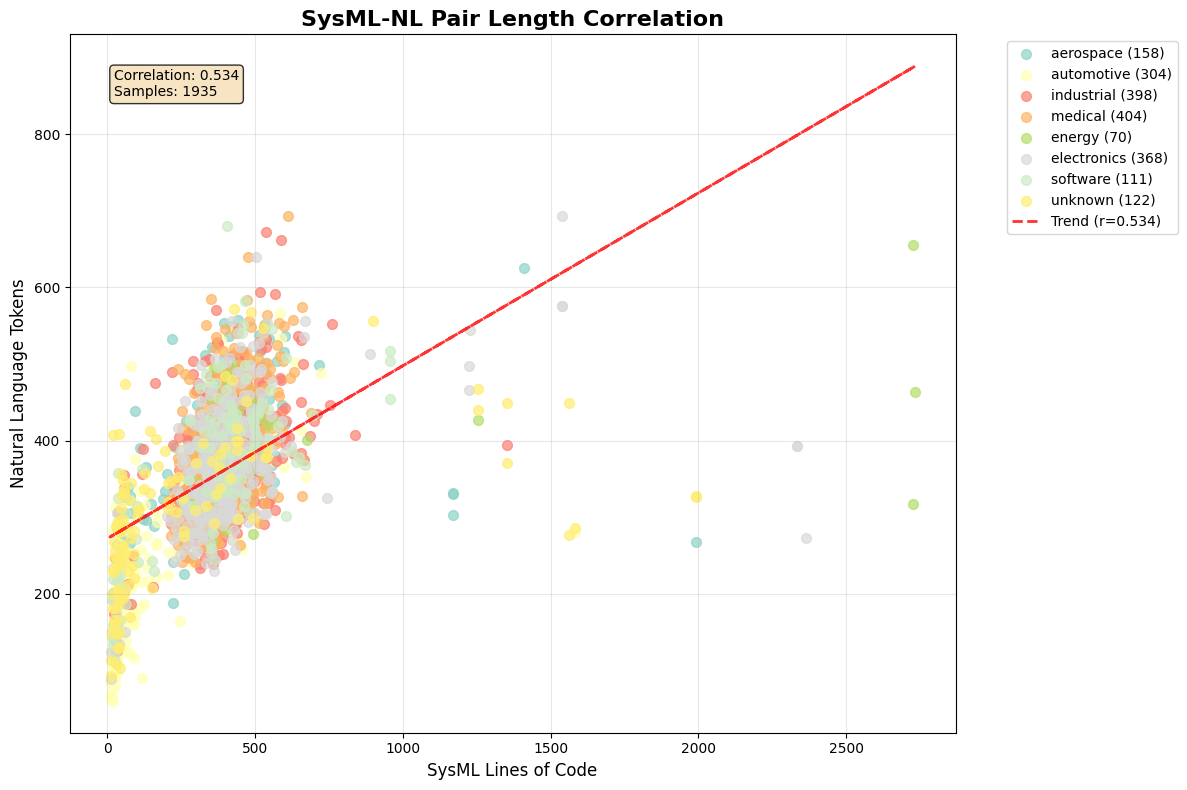


Top 10 pairs with highest SysML/NL ratio:
   1. 000355: 2365 lines / 273 tokens = 8.66
   2. 000303: 2726 lines / 317 tokens = 8.60
   3. 000367: 1991 lines / 268 tokens = 7.43
   4. 000305: 1991 lines / 326 tokens = 6.11
   5. 000352: 1991 lines / 328 tokens = 6.07
   6. 000308: 2333 lines / 393 tokens = 5.94
   7. 000370: 2333 lines / 393 tokens = 5.94
   8. 000350: 2734 lines / 463 tokens = 5.90
   9. 000311: 1564 lines / 277 tokens = 5.65
  10. 000086: 1581 lines / 281 tokens = 5.63

Top 10 pairs with lowest SysML/NL ratio:
   1. 000062:  20 lines / 219 tokens = 0.09
   2. 000036:  27 lines / 313 tokens = 0.09
   3. 000030:  20 lines / 233 tokens = 0.09
   4. 000066:  23 lines / 268 tokens = 0.09
   5. 000224:  16 lines / 192 tokens = 0.08
   6. 000070:  16 lines / 199 tokens = 0.08
   7. 000061:  18 lines / 228 tokens = 0.08
   8. 000157:  19 lines / 246 tokens = 0.08
   9. 000158:  21 lines / 283 tokens = 0.07
  10. 000068:  19 lines / 407 tokens = 0.05

Category-wise correlatio

In [5]:
# Initialize OpenAI tokenizer
encoding = tiktoken.get_encoding("cl100k_base")

pairs = []
# Collect SysML-NL pairs with their lengths
for sample_dir in sorted(dataset_dir.iterdir()):
    if sample_dir.is_dir() and sample_dir.name.isdigit():
        sysml_file = sample_dir / f"{sample_dir.name}.sysml"
        txt_file = sample_dir / f"{sample_dir.name}.txt"
        meta_file = sample_dir / "meta.json"
        
        if sysml_file.exists() and txt_file.exists():
            try:
                # Count SysML lines
                with open(sysml_file, 'r', encoding='utf-8') as f:
                    sysml_content = f.read()
                    sysml_lines = len(sysml_content.splitlines())
                
                # Count NL tokens
                with open(txt_file, 'r', encoding='utf-8') as f:
                    nl_content = f.read()
                    nl_tokens = len(encoding.encode(nl_content))
                
                # Read metadata
                category = 'unknown'
                if meta_file.exists():
                    with open(meta_file, 'r', encoding='utf-8') as f:
                        meta_data = json.load(f)
                        category = meta_data.get('category', 'unknown')
                
                pairs.append({
                    'id': sample_dir.name,
                    'sysml_lines': sysml_lines,
                    'nl_tokens': nl_tokens,
                    'category': category
                })
                
            except Exception as e:
                print(f"Error processing {sample_dir.name}: {e}")
                continue

print(f"Found {len(pairs)} SysML-NL pairs")
print(f"Total SysML lines: {sum(p['sysml_lines'] for p in pairs):,}")
print(f"Total NL tokens: {sum(p['nl_tokens'] for p in pairs):,}")

# Extract data for analysis
sysml_lengths = [p['sysml_lines'] for p in pairs]
nl_lengths = [p['nl_tokens'] for p in pairs]

# Calculate correlation
correlation = np.corrcoef(sysml_lengths, nl_lengths)[0, 1]
print(f"\nCorrelation coefficient: {correlation:.3f}")

# Statistics
print(f"\nSysML Lines Statistics:")
print(f"  Mean: {np.mean(sysml_lengths):.1f}")
print(f"  Median: {np.median(sysml_lengths):.1f}")
print(f"  Min: {min(sysml_lengths)}")
print(f"  Max: {max(sysml_lengths)}")

print(f"\nNL Tokens Statistics:")
print(f"  Mean: {np.mean(nl_lengths):.1f}")
print(f"  Median: {np.median(nl_lengths):.1f}")
print(f"  Min: {min(nl_lengths)}")
print(f"  Max: {max(nl_lengths)}")

# Create scatter plot with correlation
plt.figure(figsize=(12, 8))

# Color by category if available
categories = list(set(p['category'] for p in pairs))
colors = plt.cm.Set3(np.linspace(0, 1, len(categories)))
category_colors = {cat: colors[i] for i, cat in enumerate(categories)}

# Plot each category with different colors
for category in categories:
    cat_pairs = [p for p in pairs if p['category'] == category]
    if cat_pairs:
        cat_sysml = [p['sysml_lines'] for p in cat_pairs]
        cat_nl = [p['nl_tokens'] for p in cat_pairs]
        plt.scatter(cat_sysml, cat_nl, 
                   c=[category_colors[category]], 
                   label=f'{category} ({len(cat_pairs)})',
                   alpha=0.7, s=50)

# Add trend line
z = np.polyfit(sysml_lengths, nl_lengths, 1)
p = np.poly1d(z)
plt.plot(sysml_lengths, p(sysml_lengths), "r--", alpha=0.8, linewidth=2, label=f'Trend (r={correlation:.3f})')

plt.xlabel('SysML Lines of Code', fontsize=12)
plt.ylabel('Natural Language Tokens', fontsize=12)
plt.title('SysML-NL Pair Length Correlation', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add correlation text
plt.text(0.05, 0.95, f'Correlation: {correlation:.3f}\nSamples: {len(pairs)}', 
         transform=plt.gca().transAxes, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         verticalalignment='top')

plt.tight_layout()
plt.show()


# Show extreme cases
print("\nTop 10 pairs with highest SysML/NL ratio:")
ratio_pairs = [(p['id'], p['sysml_lines'], p['nl_tokens'], p['sysml_lines']/max(p['nl_tokens'], 1)) for p in pairs]
ratio_pairs.sort(key=lambda x: x[3], reverse=True)
for i, (id, sysml, nl, ratio) in enumerate(ratio_pairs[:10]):
    print(f"  {i+1:2d}. {id}: {sysml:3d} lines / {nl:3d} tokens = {ratio:.2f}")

print("\nTop 10 pairs with lowest SysML/NL ratio:")
for i, (id, sysml, nl, ratio) in enumerate(ratio_pairs[-10:]):
    print(f"  {i+1:2d}. {id}: {sysml:3d} lines / {nl:3d} tokens = {ratio:.2f}")

# Category-wise analysis
print("\nCategory-wise correlation:")
for category in sorted(categories):
    cat_pairs = [p for p in pairs if p['category'] == category]
    if len(cat_pairs) > 1:
        cat_sysml = [p['sysml_lines'] for p in cat_pairs]
        cat_nl = [p['nl_tokens'] for p in cat_pairs]
        cat_corr = np.corrcoef(cat_sysml, cat_nl)[0, 1]
        print(f"  {category}: r={cat_corr:.3f} (n={len(cat_pairs)})")